# Notebook 06: Location feature encoding

Raw latitude and longitude only let a linear model fit a single plane over the map, so most spatial price structure is invisible to it. This notebook builds and compares three encodings that expose that structure:

- Distance to major California cities, computed with the haversine formula
- Geohash cell membership, using a hand-rolled base32 geohash and one-hot indicators
- Rotated coordinates, the sum and difference of latitude and longitude, which align with the coastline

Continuous candidates are screened with the residual correlation scan and BH FDR correction; grouped one-hot sets are compared with cross-validation and paired t-tests, because their value comes from acting together rather than one column at a time.

## 1. Notebook set-up

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

sys.path.insert(0, str(Path.cwd().resolve().parent / 'src'))
import featurely as fl

from config import (
    DATA_DIR,
    GEOHASH_MIN_CELL_COUNT,
    GEOHASH_PRECISION,
    PIPELINE_COLORS,
    PIPELINE_RESULTS_PATH,
 )

## 2. Data loading

In [2]:
in_path = DATA_DIR / '05-p_censoring.csv'

if not in_path.exists():
    raise FileNotFoundError(
        (f'Missing required input file: {in_path}. Run 05-p_censoring.ipynb ' +
         'first to generate data/05-p_censoring.csv.')
    )

housing_df = pd.read_csv(in_path)
features = [c for c in housing_df.columns if c != 'MedHouseVal']
print(f'Loaded: {in_path}')

Loaded: /workspaces/featurely/data/fsa-feature-engineering-challenge/05-p_censoring.csv


## 3. Candidate location encodings

City distances collapse two coordinates into interpretable urban-proximity measures. Geohash cells discretize the map into rectangles whose one-hot indicators give the model a separate intercept per neighborhood; cells with fewer than the configured minimum row count are pooled into a shared other bucket. Rotated coordinates re-express location along coast-parallel and coast-perpendicular axes.

In [3]:
city_dist_df = fl.compute_city_distances(housing_df)
rotated_df = fl.compute_rotated_coordinates(housing_df)

geohash_sets = {}

for precision in (GEOHASH_PRECISION - 1, GEOHASH_PRECISION):
    cells = fl.compute_geohash_cells(
        housing_df, precision=precision, min_cell_count=GEOHASH_MIN_CELL_COUNT
    )
    geohash_sets[precision] = cells
    print(f'precision {precision}: {cells.shape[1]} cell indicator columns')

precision 3: 17 cell indicator columns


precision 4: 41 cell indicator columns


## 4. Residual scan of continuous candidates

Each continuous candidate is correlated against the residuals of a baseline linear model fit on the current features. A strong correlation means the candidate explains variance the baseline misses. BH FDR correction controls the expected fraction of false discoveries across the scan.

Baseline R2 (in-sample): 0.6999

  dist_LosAngeles: r = -0.0394,  p = 0.0000
dist_SanFrancisco: r = +0.0043,  p = 0.5402
    dist_SanDiego: r = -0.0011,  p = 0.8710
     dist_SanJose: r = +0.0065,  p = 0.3481
  dist_Sacramento: r = +0.0080,  p = 0.2477
      dist_Fresno: r = +0.0311,  p = 0.0000


dist_nearest_city: r = -0.0777,  p = 0.0000
        coord_sum: r = -0.0000,  p = 1.0000
       coord_diff: r = +0.0000,  p = 1.0000


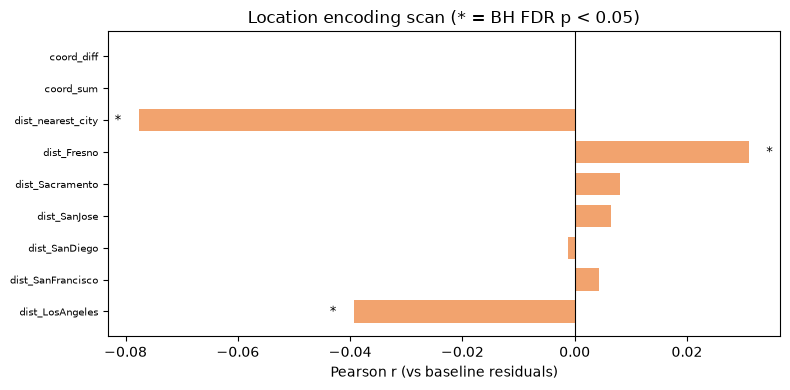

In [4]:
continuous_candidates = pd.concat([city_dist_df, rotated_df], axis=1)

scan_results = fl.run_candidate_scan(housing_df, continuous_candidates, target='MedHouseVal')

sig_dict = fl.plot_candidate_scan(
    scan_results,
    title='Location encoding scan (* = BH FDR p < 0.05)',
    color=PIPELINE_COLORS.get('+ location', '#ed7d31'),
 )

## 5. Cross-validated comparison of encoding sets

Geohash indicators act jointly, so per-column correlations understate their value. Instead we compare full encoding sets with the same 10-fold CV used across the pipeline, then run paired t-tests against the baseline with Holm-Bonferroni correction to control family-wise error rate.

In [5]:
x_base = housing_df.drop('MedHouseVal', axis=1)
y = housing_df['MedHouseVal']

encoding_sets = {
    'baseline': x_base,
    '+ city distances': pd.concat([x_base, city_dist_df], axis=1),
    '+ rotated coords': pd.concat([x_base, rotated_df], axis=1),
}

for precision, cells in geohash_sets.items():
    encoding_sets[f'+ geohash (p={precision})'] = pd.concat([x_base, cells], axis=1)

cv_encoding_results = {}

for label, x in encoding_sets.items():
    scores = cross_val_score(LinearRegression(), x, y, cv=10, scoring='r2')
    cv_encoding_results[label] = scores
    print(f'{label:>20}: mean R² = {scores.mean():.4f} ± {scores.std():.4f}')

            baseline: mean R² = 0.6120 ± 0.0564


    + city distances: mean R² = 0.6157 ± 0.0775


    + rotated coords: mean R² = 0.6120 ± 0.0564


     + geohash (p=3): mean R² = 0.6135 ± 0.0721


     + geohash (p=4): mean R² = 0.6333 ± 0.0597


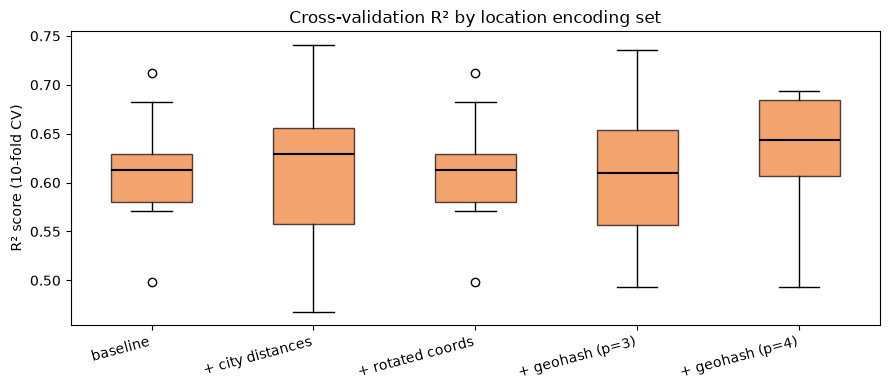


Paired t-tests vs baseline (Holm-Bonferroni; * = p_corr < 0.05):
  baseline vs   + city distances: t = -0.2534,  p_raw = 0.8057,  p_corr = 1.0000
  baseline vs   + rotated coords: t = -1.0808,  p_raw = 0.3079,  p_corr = 1.0000
  baseline vs    + geohash (p=3): t = -0.0944,  p_raw = 0.9269,  p_corr = 1.0000
  baseline vs    + geohash (p=4): t = -1.1733,  p_raw = 0.2708,  p_corr = 1.0000


In [6]:
fig, ax = plt.subplots(figsize=(9, 4))

bp = ax.boxplot(
    cv_encoding_results.values(),
    tick_labels=list(cv_encoding_results.keys()),
    patch_artist=True
)

for patch in bp['boxes']:
    patch.set_facecolor(PIPELINE_COLORS.get('+ location', '#ed7d31'))
    patch.set_alpha(0.7)

for median in bp['medians']:
    median.set(color='black', linewidth=1.5)

ax.set_title('Cross-validation R² by location encoding set')
ax.set_ylabel('R² score (10-fold CV)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

baseline_scores = cv_encoding_results['baseline']
paired_keys = [k for k in cv_encoding_results if k != 'baseline']
t_stats, p_raws = [], []

for k in paired_keys:
    t_stat, p_raw = ttest_rel(baseline_scores, cv_encoding_results[k])
    t_stats.append(t_stat)
    p_raws.append(p_raw)

reject, p_corrected, _, _ = multipletests(p_raws, alpha=0.05, method='holm')

print('\nPaired t-tests vs baseline (Holm-Bonferroni; * = p_corr < 0.05):')
improved = {}

for k, t_stat, p_raw, p_corr, rej in zip(paired_keys, t_stats, p_raws, p_corrected, reject):
    marker = ' *' if rej else ''
    print(f'  baseline vs {k:>18}: t = {t_stat:+.4f},  p_raw = {p_raw:.4f},  p_corr = {p_corr:.4f}{marker}')
    improved[k] = bool(rej) and cv_encoding_results[k].mean() > baseline_scores.mean()

## 6. Add selected location features

Continuous candidates enter the frame when they pass the BH FDR scan. The geohash set enters only if its CV improvement over the baseline is Holm-significant; when both precisions qualify, the one with the higher mean R² wins.

In [7]:
added_cols = []

sig_continuous = continuous_candidates[[c for c, s in sig_dict.items() if s]]

if not sig_continuous.empty:
    housing_df = pd.concat([housing_df, sig_continuous], axis=1)
    added_cols += list(sig_continuous.columns)

best_geohash = None
best_mean = baseline_scores.mean()

for precision in geohash_sets:
    label = f'+ geohash (p={precision})'

    if improved.get(label, False) and cv_encoding_results[label].mean() > best_mean:
        best_geohash = precision
        best_mean = cv_encoding_results[label].mean()

if best_geohash is not None:
    housing_df = pd.concat([housing_df, geohash_sets[best_geohash]], axis=1)
    added_cols += list(geohash_sets[best_geohash].columns)
    print(f'Added geohash precision {best_geohash} cell indicators.')

print(f'Added {len(added_cols)} location feature(s) total.')

Added 3 location feature(s) total.


## 7. Performance evaluation

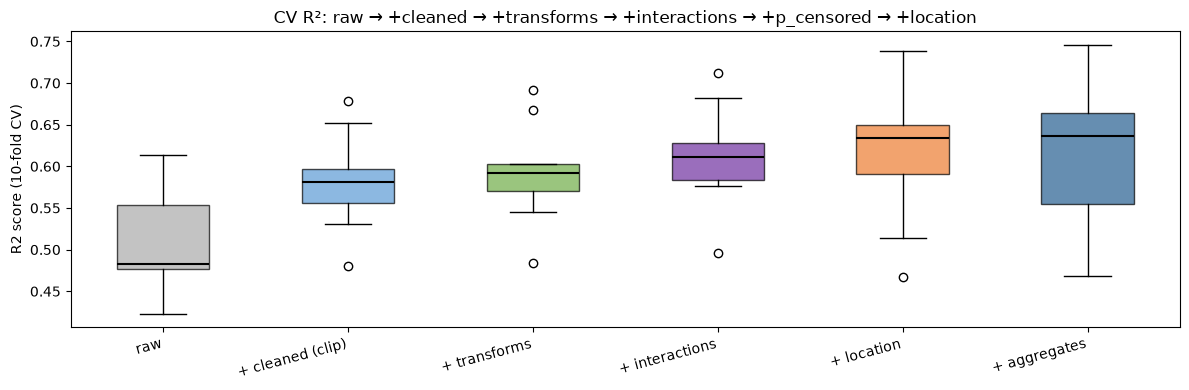

                      raw: mean R2 = 0.5110 ± 0.0593  (+0.00% vs raw)
         + cleaned (clip): mean R2 = 0.5811 ± 0.0536  (+13.71% vs raw)
             + transforms: mean R2 = 0.5923 ± 0.0551  (+15.90% vs raw)
           + interactions: mean R2 = 0.6122 ± 0.0561  (+19.81% vs raw)
               + location: mean R2 = 0.6201 ± 0.0786  (+21.34% vs raw)
             + aggregates: mean R2 = 0.6199 ± 0.0851  (+21.31% vs raw)


In [8]:
results_df = fl.add_pipeline_step(
    None,
    '+ location',
    housing_df.drop('MedHouseVal', axis=1),
    housing_df['MedHouseVal'],
    color=PIPELINE_COLORS.get('+ location', '#ed7d31'),
    results_path=PIPELINE_RESULTS_PATH,
 )

fl.plot_pipeline_steps(
    results_df,
    title='CV R²: raw → +cleaned → +transforms → +interactions → +p_censored → +location',
    results_path=PIPELINE_RESULTS_PATH,
 )

## 8. Save output

In [9]:
out_path = DATA_DIR / '06-location-feature-encoding.csv'
housing_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

Saved: /workspaces/featurely/data/fsa-feature-engineering-challenge/06-location-feature-encoding.csv
